# SmallWorld Brian2 

In [1]:
!pip install brian2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 7.6 MB/s eta 0:00:0000:01:00:01


## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from brian2 import *
import seaborn as sns

## Config

In [ ]:
# ================================================
# CONFIG — To modify the parameters
# ================================================
config = {
    # --- Network (Watts-Strogatz) ---
    "N": 100,
    "k": 10,
    "beta": 0.25,
    "seed_graph": 123,
    "seed_weights": 42,
    "W_scale": 100.0,
    "inhib_threshold": 10,
    "long_range_type": "inhibitory",  # or "excitatory"

    # --- Dale's law (Shanahan 2008 convention) ---
    "seed_dale": 999,
    "dale_frac_exc": 0.8,
    "frac_inhibitory": 0.2,
    "w_exc_max": 1.0,
    "w_inh_max": 2.0,

    # --- Neuron model ---
    "neuron_model": "LIF",

    # --- H2: thickness-dependent conduction delay (off by default) ---
    "enable_thickness_delay": False,
    "delay_mode": "uniform",
    "conduction_velocity_local": 2.0,
    "conduction_velocity_long_range": 8.0,
    "min_delay": 0.1,

    # --- Conduction delays (H2 mise à jour) ---
    "use_conduction_delays": False,
    "delay_distance_threshold": 10,
    "v_local": 2.0,
    "v_long": 2.0,
    "delay_min": 0.1,

    # --- H3: thickness-dependent weight boost (off by default) ---
    "enable_thickness_weight": False,
    "w_longrange_boost": 2.0,

    # --- Neurons (LIF) ---
    "gL": 0.5,
    "EL": -50.0,
    "Vthreshold": 30.0,
    "Vreset": -60.0,
    "sigma": 10.0,
    "delta_spike": 1.0,

    # --- Neurons (Izhikevich, only used if neuron_model=="Izhikevich") ---
    "izh_a": 0.02,
    "izh_b": 0.2,
    "izh_c": -65.0,
    "izh_d": 8.0,
    "izh_I_scale": 1.0,

    # --- Simulation ---
    "duration": 200,
    "dt": 0.01,

    # --- Inputs ---
    "I_static_scale": 10.0,
    "I_oscillatory_scale": 6.0,
    "I_bump_amplitude": 30.0,
    "I_bump_width_factor": 10.0,
    "I_oscillatory_frequency": 2.0,
    "I_phase_switch_time": 100.0,
}


## Functions

In [ ]:
# ================================================
# FUNCTION: build_network(config)
# ================================================
def build_network(config):
    """
    Build the network Watts-Strogatz and the synaptic weights matrix,
    respecting Dale's law following the Shanahan (2008) convention:
    each neuron's identity (excitatory/inhibitory) is fixed once, and
    ALL of its outgoing synapses share that sign. Inhibitory neurons
    are also kept local only (as in Shanahan, where inhibitory
    connections are left untouched by the rewiring phase, i.e. only
    excitatory connections can become long-range shortcuts).

    Parameters
    ----------
    config: dict

    Returns
    -------
    A: np.ndarray (N x N) - adjacency matrix, connectivity (0/1)
    M: np.ndarray (N x N) - signed weight matrix (before masking by A)
    Wsyn_matrix: np.ndarray (N x N) - final synaptic weights matrix
    G_nx: networkx.Graph - underlying Watts-Strogatz graph
    is_inhibitory: np.ndarray (N,) bool - neuron identity (True=inhibitory)
    """
    N = config["N"]
    beta = config["beta"]
    k = config["k"]
    inhib_threshold = config["inhib_threshold"]
    frac_inhibitory = config["frac_inhibitory"]
    w_exc_max = config["w_exc_max"]
    w_inh_max = config["w_inh_max"]

    # Watts-Strogatz graph
    G_nx = nx.watts_strogatz_graph(n=N, k=k, p=beta, seed=config["seed_graph"])
    A = nx.to_numpy_array(G_nx)

    np.random.seed(config["seed_weights"])

    """
    # Neuron identity fixed ONCE per neuron (Shanahan 2008: ~80% exc / 20% inhib)
    #is_inhibitory = np.random.rand(N) < frac_inhibitory
    """
    is_exc = assign_neuron_types(config)
    is_inhibitory = ~is_exc 
    

    # Signed weight matrix M, convention [post, pre] (row=post, column=pre)
    # Excitatory neuron: every outgoing weight is positive, drawn in [0, w_exc_max]
    # Inhibitory neuron: every outgoing weight is negative, drawn in [-w_inh_max, 0]
    M = np.zeros((N, N))
    for idx_pre in range(N):
        if is_inhibitory[idx_pre]:
            M[:, idx_pre] = -w_inh_max * np.random.rand(N)
        else:
            M[:, idx_pre] = w_exc_max * np.random.rand(N)

    # Shanahan convention (default): inhibitory connections stay LOCAL (never
    # long-range), only excitatory neurons project across long distances.
    # H1: compare both
    long_range_type = config.get("long_range_type", "inhibitory")
    restricted_type_is_inhibitory = (long_range_type == "excitatory")
    for idx_pre in range(N):
        if is_inhibitory[idx_pre] == restricted_type_is_inhibitory:
            for idx_post in range(N):
                distance = abs(idx_post - idx_pre)
                is_long_range = distance > inhib_threshold and distance < (N - inhib_threshold)
                if is_long_range:
                    M[idx_post, idx_pre] = 0.0  # Remove long-range connections for the restricted type
    # H3: optionally boost the weight of long-range connections, as a proxy
    # for thicker neurites carrying a stronger synaptic signal (independent
    # of the E/I sign question tested in H1).
    if config.get("enable_thickness_weight", False):
        w_boost = config.get("w_longrange_boost", 2.0)
        for idx_pre in range(N):
            for idx_post in range(N):
                distance = abs(idx_post - idx_pre)
                is_long_range = distance > inhib_threshold and distance < (N - inhib_threshold)
                if is_long_range and M[idx_post, idx_pre] != 0:
                    M[idx_post, idx_pre] *= w_boost

    # Final synaptic weights matrix
    # FIX: was "A @ M" (matrix product), which produced a near-complete graph
    # (~99% density) regardless of beta/k, ignoring the Watts-Strogatz
    # topology in A. Switched to the elementwise Hadamard product so only
    # real graph edges get a nonzero weight, matching plot_connectivity().
    Wsyn_matrix = config["W_scale"] * (A @ M)

    return A, M, Wsyn_matrix, G_nx, is_inhibitory


In [ ]:
# ================================================
# FUNCTION : assign_neuron_types(config)
# ================================================
def assign_neuron_types(config):
    """
    Assigns a fixed type (excitatory/inhibitory) to each neuron,
    in accordance with Dale's rule (all outgoing synapses
    from a neuron have the same sign).

    Returns
    --------
    is_exc : np.ndarray(bool), shape (N,) — True si excitateur
    """
    rng = np.random.RandomState(config["seed_dale"])
    is_exc = rng.rand(config["N"]) < config["dale_frac_exc"]
    return is_exc


# ================================================
# FUNCTION : ring_distance_matrix(N)
# ================================================
def ring_distance_matrix(N):
    """Circular distance (1D ring) between each pair of neurons."""
    idx = np.arange(N)
    diff = np.abs(idx[:, None]-idx[None, :])
    return np.minimum(diff, N-diff)


In [ ]:
# ================================================
# FUNCTION : build_delays(config) 
# ================================================
def build_delays(config):
    """
    Builds the conduction delay matrix (N x N), in ms.
    
    Hypothesis : long-distance connections (thicker neurites)
    conduct faster than local connections (thinner neurites).
    
    Modes :
    - use_conduction_delays=False : zero delay everywhere (baseline)
    - use_conduction_delays=True, v_long=v_local : delay identical everywhere (control)
    - use_conduction_delays=True, v_long>v_local : differentiated delay (H2 hypothesis)
    
    Returns
    --------
    delay_matrix : np.ndarray (N, N) — delay in ms for each pair (post, pre)
    """
    N = config["N"]
    dist = ring_distance_matrix(N)
    
    if not config.get("use_conduction_delays", False):
        return np.zeros((N, N))  # Baseline: no delays
    
    delay_distance_threshold = config.get("delay_distance_threshold", 10)
    v_local = config.get("v_local", 2.0)
    v_long = config.get("v_long", 2.0)
    delay_min = config.get("delay_min", 0.1)
    
    velocity = np.where(dist <= delay_distance_threshold, v_local, v_long)
    delay_matrix = dist / velocity
    delay_matrix = np.clip(delay_matrix, delay_min, None)
    return delay_matrix


In [ ]:
# ================================================
# FUNCTION : build_inputs(config)
# ================================================
def build_inputs(config):
    """
    Build the TimedArray Brian2 for the inputs (constant and oscillatory)

    Parameters
    ----------
    config : dict

    Returns
    --------
    I_constant_input : TimedArray — constant input current
    I_oscillatory_input : TimedArray — oscillatory spatiotemporal input
    I_oscillatory_matrix : np.ndarray (time_steps × N) — raw values
    t_vec : np.ndarray (time_steps,)    — time vector (Brian2 units)
    time_steps : int
    """

    N = config["N"]
    beta = config["beta"]
    duration = config["duration"] * ms
    dt = config["dt"] * ms

    time_steps = int(duration / dt) + 1
    t_vec = np.arange(time_steps) * dt

    # -----------------------------------------------
    # Constant input current  I(t) = I_static_scale * beta
    # -----------------------------------------------
    I_static_profile = (config["I_static_scale"] * np.ones(N) * beta + 0.0) * (mV / ms)
    I_matrix = np.tile(I_static_profile, (time_steps, 1))
    I_constant_input = TimedArray(I_matrix, dt=dt)

    # -----------------------------------------------
    # Spatiotemporal oscillatory input
    # -----------------------------------------------
    I_oscillatory_matrix = np.zeros((time_steps, N))

    for idx_t, t_val in enumerate(t_vec):
        phase_shift = np.pi / 2.0 if t_val > config["I_phase_switch_time"] * ms else 0.0
        oscillatory_shift = (N / 2.0) * np.sin(config["I_oscillatory_frequency"] * 2.0 * np.pi * (t_val / ms) / 200.0 + phase_shift)
        x_coord = -N / 2.0 + oscillatory_shift + (np.arange(N) * (N / (N - 1.0)))
        bump = config["I_bump_amplitude"] * np.exp(-(x_coord**2) / (N / config["I_bump_width_factor"])**2) * np.exp(-((t_val / ms) - 100.0) / 1e6)
        I_oscillatory_matrix[idx_t, :] = config["I_oscillatory_scale"] * beta + bump

    I_oscillatory_input = TimedArray(I_oscillatory_matrix * (mV / ms), dt=dt)

    return I_constant_input, I_oscillatory_input, I_oscillatory_matrix, t_vec, time_steps

In [ ]:
# ================================================
# FUNCTION: run_simulation(config, verbose=True)
# ================================================
def run_simulation(config, verbose=True):
    """
    Run the complete Brian2 simulation (network + inputs + neurons, synapses, monitors)

    Parameters
    ----------
    config: dict
    verbose: bool - shows progress if True

    Returns
    -------
    spike_mon: SpikeMonitor
    state_mon: StateMonitor
    I_oscillatory_matrix: np.ndarray - input oscillatory raw values (time_steps x N)
    t_vec: np.ndarray - time vector (Brian2 units)
    time_steps: int
    A: np.ndarray - adjacency matrix (connectivity)
    M: np.ndarray - signed weight matrix
    Wsyn_matrix: np.ndarray - final synaptic weights matrix
    G_nx: networkx.Graph - underlying Watts-Strogatz graph
    is_inhibitory: np.ndarray (N,) bool - neuron identity
    """
    start_scope()

    N = config["N"]
    neuron_model = config.get("neuron_model", "LIF")

    # ---- Network ----
    A, M, Wsyn_matrix, G_nx, is_inhibitory = build_network(config)

    # ---- Inputs ----
    I_constant_input, I_oscillatory_input, I_oscillatory_matrix, t_vec, time_steps = build_inputs(config)

    # ---- Simulation parameters ----
    duration = config["duration"] * ms
    defaultclock.dt = config["dt"] * ms

    delta_spike = config["delta_spike"]

    if neuron_model == "LIF":
        gL_val = config["gL"] / ms
        sigma = np.sqrt(config["sigma"]) * (mV / sqrt(ms))
        Vthreshold = config["Vthreshold"] * mV
        Vreset = config["Vreset"] * mV
        EL = config["EL"] * mV

        # ================================================
        # LIF EQUATIONS (membrane potential V + adaptation variable Z + synaptic current S)
        # xi = white gaussian noise from Brian2
        # ================================================
        eqs = """
            dV/dt = -gL * Z * (V - EL) + I_oscillatory_input(t, i) + (S * mV / ms) + sigma*xi : volt
            dS/dt = -S / ms : 1
            dZ/dt = -0.01 * Z / ms : 1
            gL : 1/second
        """

        neurons = NeuronGroup(
            N,
            model=eqs,
            threshold="V > Vthreshold",
            reset="V = Vreset; Z += 0.05 * delta_spike",
            method="euler"
        )
        neurons.gL = gL_val
        neurons.V = (30.0 * np.random.randn(N)) * mV
        neurons.Z = np.random.rand(N)
        neurons.S = 100.0 * np.random.rand(N)

    elif neuron_model == "Izhikevich":
        izh_a = config["izh_a"] / ms
        izh_b = config["izh_b"] / ms
        izh_c = config["izh_c"] * mV
        izh_d = config["izh_d"] * mV / ms
        izh_I_scale = config["izh_I_scale"]

        # ================================================
        # IZHIKEVICH EQUATIONS (Izhikevich 2003, rescaled to Brian2 units)
        # V plays the role of Izhikevich's v (membrane potential-like variable)
        # Z plays the role of Izhikevich's u (recovery/adaptation variable)
        # -- kept as V/Z (rather than v/u) so state_mon.V, state_mon.Z, and
        # plot_adaptation/plot_synaptic/plot_voltage work unchanged for both models.
        # S plays the same role as in the LIF version (synaptic current, tau=1ms)
        # ================================================
        eqs = """
            dV/dt = (0.04/mV/ms*V**2 + 5/ms*V + 140*mV/ms - Z + izh_I_scale*I_oscillatory_input(t, i) + (S * mV / ms)) : volt
            dZ/dt = izh_a * (izh_b*V - Z) : volt/second
            dS/dt = -S / ms : 1
        """

        neurons = NeuronGroup(
            N,
            model=eqs,
            threshold="V > 30*mV",
            reset="V = izh_c; Z += izh_d",
            method="euler"
        )
        neurons.V = izh_c
        neurons.Z = izh_b * izh_c
        neurons.S = 100.0 * np.random.rand(N)

    else:
        raise ValueError(f"Unknown neuron_model: {neuron_model!r} (expected 'LIF' or 'Izhikevich')")

    # ---- Synapses ----
    # NOTE (fix): using "S = clip(S + delta_spike*w, 0, 100)" is order-dependent when several synapses fire onto the same neuron in the same timestep (Brian2 warning).
    # We instead accumulate commutatively with "+=", then clip S exactly once per timestep (after all synaptic events of that step, via run_regularly).
    synapses = Synapses(
        neurons, neurons,
        model="w : 1",
        on_pre="S += delta_spike * w"
    )

    targets, sources = np.nonzero(Wsyn_matrix)
    synapses.connect(i=sources, j=targets)
    synapses.w = Wsyn_matrix[targets, sources]

    # H2: optional distance/thickness-dependent conduction delay
    if config.get("use_conduction_delays", False):          
        Delay_matrix = build_delays(config)
        synapses.delay = Delay_matrix[targets, sources] * ms

    neurons.run_regularly("S = clip(S, 0, 100)", when="resets", order=1)

    # ---- Monitors ----
    spike_mon = SpikeMonitor(neurons)
    state_mon = StateMonitor(neurons, ["V", "S", "Z"], record=True)

    # ---- Run ----
    run(duration, report="text" if verbose else None)

    return spike_mon, state_mon, I_oscillatory_matrix, t_vec, time_steps, A, M, Wsyn_matrix, G_nx, is_inhibitory


In [ ]:
# ================================================
# FUNCTIONS FOR VISUALIZATION
# ================================================

def plot_connectivity(A, M, config):
    """Display the connectivity matrix"""
    plt.figure(figsize=(10, 5))
    plt.imshow( A * M, aspect='auto', cmap='bwr', vmin=-1, vmax=1, origin='lower')
    plt.colorbar(ticks=[-1, 0, 1], label="Edge weight")
    plt.xlabel("Presynaptic neuron index")
    plt.ylabel("Postsynaptic neuron index")
    plt.title(f"Connectivity matrix of the network (beta={config['beta']})")
    plt.show()


def plot_oscillatory_input(I_oscillatory_matrix, t_vec, config):
    """Display the spatiotemporal view of the oscillatory input"""
    t_vec_ms = t_vec / ms
    plt.figure(figsize=(10, 5))
    plt.imshow(I_oscillatory_matrix.T, aspect='auto', origin='lower',
               extent=[t_vec_ms[0], t_vec_ms[-1], 0, config["N"]], cmap='viridis')
    plt.colorbar(label="Input Current amplitude")
    plt.xlabel("Time (ms)")
    plt.ylabel("Neuron Index (Space)")
    plt.title("Spatiotemporal view: Movement of the activation bump across the network")
    plt.show()


def plot_raster(spike_mon, t_vec, config):
    """Display the raster plot + the reference oscillatory wave"""
    N = config["N"]
    time_steps = len(t_vec)

    plt.figure(figsize=(12, 6))

    # spikes
    spikes_t = spike_mon.t / ms
    spikes_i = spike_mon.i
    plt.scatter(spikes_t, spikes_i, marker='|', color='black', s=10, linewidths=0.5)

    # oscillatory input
    tvec = np.arange(time_steps) * (config["dt"])  # in ms
    phase_shift = np.where(tvec > 100.0, np.pi / 2.0, 0.0)
    blue_wave = (
        -np.sin(config["I_oscillatory_frequency"] * 2.0 * np.pi * tvec / 200.0 + phase_shift) + 1.0
    ) * N / 2.0
    plt.scatter(tvec, blue_wave, s=2, color='blue', edgecolors='none')

    plt.xlabel("time")
    plt.ylabel("Neuron index")
    plt.show()


def plot_adaptation(state_mon, config):
    """Display the dynamics of the adaptation variable Z"""
    plot_step_z = 100
    time_ms = state_mon.t / ms
    plt.figure(figsize=(12, 6))
    for i in range(config["N"]):
        plt.plot(time_ms[10::plot_step_z], state_mon.Z[i][10::plot_step_z])
    plt.xlabel("Time (ms)")
    plt.ylabel("Z (Adaptation)")
    plt.title("Dynamics of the adaptation variable Z for each neuron")
    plt.show()


def plot_synaptic(state_mon, config):
    """Display the dynamics of the synaptic current S (initial phase)"""
    time_ms = state_mon.t / ms
    plt.figure(figsize=(12, 6))
    for i in range(config["N"]):
        plt.plot(time_ms[10:1000:1], state_mon.S[i][10:1000:1], linewidth=1.5)
    plt.xlabel("Time (ms)")
    plt.ylabel("S (Synaptic Current)")
    plt.title("Dynamics of the synaptic current S for each neuron (Initial phase)")
    plt.show()


def plot_voltage(state_mon, config):
    """Display the dynamics of the membrane potential V for a few neurons"""
    time_ms = state_mon.t / ms
    plt.figure(figsize=(12, 6))
    for i in [1, 2]:   # neurons 2 and 3 (indexation 0-based Python)
        plt.plot(time_ms[10::1], state_mon.V[i][10::1] / mV, linewidth=1.5)
    plt.xlabel("Time (ms)")
    plt.ylabel("V (mV)")
    plt.title("Membrane potential dynamics for a few neurons")
    plt.show()


def plot_results(spike_mon, state_mon, A, M, I_oscillatory_matrix, t_vec, config):
    """Launch the entire set of plots."""
    plot_connectivity(A, M, config)
    plot_oscillatory_input(I_oscillatory_matrix, t_vec, config)
    plot_raster(spike_mon, t_vec, config)
    plot_adaptation(state_mon, config)
    plot_synaptic(state_mon, config)
    plot_voltage(state_mon, config)

### Metrics

In [ ]:
# ================================================
# FUNCTION : compute_metrics(G_nx, config)
# ================================================
def compute_metrics(spike_mon, config):
    """
    Compute the key metrics after simulation

    Parameters
    ----------
    spike_mon : SpikeMonitor
    config : dict

    Returns
    --------
    dict with :
      - active_neurons    
      - firing_rates (Hz)
      - mean_firing_rate (Hz)
      - std_firing_rate (Hz)
      - synchrony_index  
    """

    N = config["N"]
    duration_s = config["duration"] / 1000.0   # ms → seconds

    spike_trains = spike_mon.spike_trains()
    firing_rates = [len(spike_trains[i]) / duration_s for i in range(N)]

    # Synchrony : variability of the mean binned activity (10 ms)
    bin_size = 10  # ms
    bins = np.arange(0, config["duration"] + bin_size, bin_size)
    counts = np.array([np.histogram(np.array(spike_trains[i]) / ms, bins)[0] for i in range(N)])
    mean_activity = counts.mean(axis=0)
    synchrony = mean_activity.std() / (mean_activity.mean() + 1e-9)

    return {
        "active_neurons" : int(np.sum(np.array(firing_rates) > 0)),
        "firing_rates" : firing_rates,
        "mean_firing_rate": np.mean(firing_rates),
        "std_firing_rate" : np.std(firing_rates),
        "synchrony_index" : synchrony,
    }

In [ ]:
# ================================================
# FUNCTION : compute_network_metrics(G_nx, config)
# ================================================
def compute_network_metrics(G_nx, config):
    """
    Compute topological (small-world) metrics of the Watts-Strogatz graph.

    C : average clustering coefficient (local density)
    L : characteristic path length (global integration)
    omega : omega ≈ 0 => small-world 
            omega→ -1 => lattice 
            omega → +1 +> random 
            

    Omega compares network clustering to an equivalent lattice network,
    and path length to an equivalent random network. omega ∈ [-1, 1]

    Parameters
    ----------
    G_nx : networkx.Graph — Watts-Strogatz graph (from build_network)
    config : dict

    Returns
    -------
    dict with keys: C, L, omega
    """
    N = config["N"]
    C = nx.average_clustering(G_nx)
    try:
        L = nx.average_shortest_path_length(G_nx)
    except nx.NetworkXError:
        L = np.nan
    try:
        omega = nx.omega(G_nx, niter=1, nrand=5, seed=config["seed_graph"]) #niter/nrand to increase for greater accuracy, but that becomes computationally expensive
    except (nx.NetworkXError, ZeroDivisionError):
        omega = np.nan

    return {"C": C, "L": L, "omega": omega}


In [ ]:
# ================================================
# FUNCTION : compute_isi_cv(spike_mon, config)
# ================================================
def compute_isi_cv(spike_mon, config):
    """
        Compute the coefficient of variation (CV) of the inter-spike intervals (ISI) 
        for each neuron, then average across the population (→ firing regularity).
    
        CV ~ 1   -> Poisson-like (irregular, random) firing
        CV < 1   -> regular firing
        CV > 1   -> bursty firing

        CV2 is robust against non-stationarity (slow changes in firing rate)
                
        CV2 ~ 0 -> very regular locally
        CV2 ~ 1 -> highly irregular/bursty locally
    
        Parameters
        ----------
        spike_mon : SpikeMonitor
        config : dict
    
        Returns
        -------
        isi_cv_mean : float — mean CV across neurons that spiked more than twice
        isi_cv_std  : float — std of the CV across those neurons
        """
    
    N = config["N"]
    spike_trains = spike_mon.spike_trains()
    cvs = []
    cv2s = []
    
    for i in range(N):
        spikes = np.array(spike_trains[i] / ms)
        if len(spikes) > 2:
            isi = np.diff(spikes)
            if isi.mean() > 0:
                # 1. CV  (global)
                cvs.append(isi.std() / isi.mean())

                # 2. CV2 (local) - standard formula from Holt et al. (1996)
                if len(isi) > 1:
                    # Formula : 2 * |ISI_{i+1} - ISI_i| / (ISI_{i+1} + ISI_i)
                    numerators = 2.0 * np.abs(np.diff(isi))
                    denominators = isi[:-1] + isi[1:]
                    # Avoid divisions by zero if two consecutive spikes have a zero ISI (very rare)
                    valid = denominators > 0
                    if np.any(valid):
                        cv2_i = np.mean(numerators[valid] / denominators[valid])
                        cv2s.append(cv2_i)
            

    isi_cv_mean = float(np.mean(cvs)) if cvs else np.nan
    isi_cv_std = float(np.std(cvs)) if cvs else np.nan
    
    isi_cv2_mean = float(np.mean(cv2s)) if cv2s else np.nan
    isi_cv2_std = float(np.std(cv2s)) if cv2s else np.nan
    
    return {
        "cv_mean": isi_cv_mean, 
        "cv_std": isi_cv_std, 
        "cv2_mean": isi_cv2_mean, 
        "cv2_std": isi_cv2_std
    }


In [13]:
# ================================================
# FUNCTION: compute_tracking_metrics(spike_mon, config)
# ================================================
def compute_tracking_metrics(spike_mon, config, bin_size=5.0):
    """
    Quantify how well the population activity tracks the moving
    oscillatory input bump (the blue reference wave plotted in plot_raster).

    At each time bin, the population centroid is the spike-count-weighted
    mean neuron index of all spikes in that bin. It is compared to the
    target bump position (identical formula to the blue wave in plot_raster) via:

    tracking_corr: Pearson correlation between centroid and target
                   trajectories (1 = perfectly follows the target)
    tracking_rmse: root-mean-square error between centroid and target,
                   normalized by N (0 = perfect overlap)
    coverage: fraction of time bins with >=1 spike (low coverage means
              corr/rmse rest on fewer points and are less reliable)

    Parameters
    ----------
    spike_mon: SpikeMonitor
    config: dict
    bin_size: float, ms - width of the bins used for the population centroid

    Returns
    -------
    dict with keys: tracking_corr, tracking_rmse, coverage
    """
    N = config["N"]
    duration = config["duration"]

    bins = np.arange(0, duration + bin_size, bin_size)
    bin_centers = (bins[:-1] + bins[1:]) / 2.0

    spikes_t = spike_mon.t / ms
    spikes_i = spike_mon.i

    centroid = np.full(len(bin_centers), np.nan)
    for b in range(len(bin_centers)):
        mask = (spikes_t >= bins[b]) & (spikes_t < bins[b + 1])
        if mask.sum() > 0:
            centroid[b] = spikes_i[mask].mean()

    coverage = float(np.mean(~np.isnan(centroid)))

    # Target trajectory: identical formula to the blue reference wave in plot_raster()
    phase_shift = np.where(bin_centers > 100.0, np.pi / 2.0, 0.0)
    target = (
        -np.sin(config["I_oscillatory_frequency"] * 2.0 * np.pi * bin_centers / 200.0 + phase_shift) + 1.0
    ) * N / 2.0

    valid = ~np.isnan(centroid)
    if valid.sum() < 2:
        return {"tracking_corr": np.nan, "tracking_rmse": np.nan, "coverage": coverage}

    tracking_corr = float(np.corrcoef(centroid[valid], target[valid])[0, 1])
    tracking_rmse = float(np.sqrt(np.mean((centroid[valid] - target[valid]) ** 2)) / N)

    return {
        "tracking_corr": tracking_corr,
        "tracking_rmse": tracking_rmse,
        "coverage": coverage,
    }


In [ ]:
# ================================================
# FONCTIONS : decode de position + tracking_score (version corrigee)
# ================================================
def compute_bump_center(t_vec_ms, config):
    """Theoretical center of the bump (same formula as the blue curve in plot_raster)."""
    N = config["N"]
    phase_shift = np.where(t_vec_ms > config["I_phase_switch_time"], np.pi / 2.0, 0.0)
    bump_center = (-np.sin(config["I_oscillatory_frequency"] * 2.0 * np.pi * t_vec_ms / 200.0 + phase_shift) + 1.0) * N / 2.0
    return bump_center


def circular_error(a, b, N):
    """Shortest signed error on the ring, in [-N/2, N/2]."""
    diff = a - b
    return ((diff + N / 2) % N) - N / 2


def decode_population_position(spike_indices, N):
    """
    Decoded position = circular average of the indices of the active neurons in a bin.
    Also returns r = the length of the resulting vector (concentration; 0 = dispersed, 1 = perfectly concentrated).
    CAUTION: r = 1 means that the activity is concentrated somewhere, but not necessarily in the right place.
    """
    if len(spike_indices) == 0:
        return np.nan, 0.0
    theta = 2 * np.pi * np.asarray(spike_indices) / N
    C = np.sum(np.cos(theta))
    S = np.sum(np.sin(theta))
    n = len(spike_indices)
    r = np.sqrt(C**2 + S**2) / n
    if C == 0 and S == 0:
        return np.nan, 0.0
    decoded_theta = np.arctan2(S, C)
    decoded_pos = (decoded_theta / (2 * np.pi) * N) % N
    return decoded_pos, r


def localization_fraction(spike_indices, true_pos, N, tolerance):
    """Fraction of the spikes in the bin whose circular distance to the bump is < tolerance."""
    if len(spike_indices) == 0:
        return np.nan
    dist = np.abs(circular_error(np.asarray(spike_indices), true_pos, N))
    return np.mean(dist < tolerance)


def compute_raster_bump_tracking(spike_mon, config, bin_size=5,
                                  transient_cutoff_ms=50, tolerance_fraction=0.1):
    """
    Measures how closely the raster follows the input bump.

    Parameters
    ----------
    spike_mon : SpikeMonitor
    config : dict
    bin_size : float — size of the temporal bins (ms)
    transient_cutoff_ms : float — initial duration excluded from the score calculation
                             (kept in the plots to visualize the transient)
    tolerance_fraction : float — tolerance window for "near the bump",
                             as a fraction of N (e.g., 0.1 = 10% of the ring)

    Returns
    -------
    dict with, for ALL bins (useful for plots) :
      - t_bins, true_position, decoded_position, concentration_r, frac_near_bump
    and the aggregated scores OVER THE POST-TRANSIENT PART ONLY :
      - tracking_score : mean of frac_near_bump (bins post-transient) -- MAIN METRIC
      - mean_concentration : mean of r (diagnostic)
      - mean_abs_error : mean of the circular position error (diagnostic)
      - coverage : fraction of post-transient bins having at least 1 spike
      - transient_cutoff_ms : rappel du parametre utilise
    """
    N = config["N"]
    duration = config["duration"]
    tolerance = N * tolerance_fraction

    bins = np.arange(0, duration + bin_size, bin_size)
    t_bins = (bins[:-1] + bins[1:]) / 2.0

    spikes_t = spike_mon.t / ms
    spikes_i = spike_mon.i[:]
    bin_idx = np.clip(np.digitize(spikes_t, bins) - 1, 0, len(t_bins) - 1)

    true_position = compute_bump_center(t_bins, config)
    decoded_position = np.full(len(t_bins), np.nan)
    concentration_r = np.full(len(t_bins), np.nan)
    frac_near_bump = np.full(len(t_bins), np.nan)

    for b in range(len(t_bins)):
        idx_in_bin = spikes_i[bin_idx == b]
        decoded_position[b], concentration_r[b] = decode_population_position(idx_in_bin, N)
        frac_near_bump[b] = localization_fraction(idx_in_bin, true_position[b], N, tolerance)

    abs_error = np.abs(circular_error(decoded_position, true_position, N))

    # ---- Aggregation on the post-transient part only ----
    post_mask = t_bins >= transient_cutoff_ms
    valid_post = post_mask & ~np.isnan(frac_near_bump)

    tracking_score = np.nanmean(frac_near_bump[post_mask]) if valid_post.any() else np.nan
    mean_concentration = np.nanmean(concentration_r[post_mask]) if valid_post.any() else np.nan
    mean_abs_error = np.nanmean(abs_error[post_mask]) if valid_post.any() else np.nan
    coverage = valid_post.sum() / post_mask.sum() if post_mask.sum() > 0 else np.nan

    return {
        "t_bins": t_bins,
        "true_position": true_position,
        "decoded_position": decoded_position,
        "concentration_r": concentration_r,
        "frac_near_bump": frac_near_bump,
        "abs_error": abs_error,
        "tracking_score": tracking_score,
        "mean_concentration": mean_concentration,
        "mean_abs_error": mean_abs_error,
        "coverage": coverage,
        "transient_cutoff_ms": transient_cutoff_ms,
    }


def plot_raster_with_decode(spike_mon, tracking, config):
    """Raster + bump theorique + position decodee + fraction localisee, avec zone transitoire ombragee."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                    gridspec_kw={"height_ratios": [2.5, 1]})

    spikes_t = spike_mon.t / ms
    spikes_i = spike_mon.i
    ax1.scatter(spikes_t, spikes_i, marker="|", color="black", s=10, linewidths=0.5, label="spikes")
    ax1.plot(tracking["t_bins"], tracking["true_position"], color="blue", lw=2, label="bump theorique")
    ax1.scatter(tracking["t_bins"], tracking["decoded_position"], color="orange", s=14,
                zorder=5, label="position decodee (moy. circulaire)")
    ax1.axvspan(0, tracking["transient_cutoff_ms"], color="gray", alpha=0.15,
                label="zone transitoire (exclue du score)")

    score_str = f"{tracking['tracking_score']:.3f}"
    conc_str = f"{tracking['mean_concentration']:.3f}"
    ax1.set_ylabel("Neuron index")
    ax1.set_title("tracking_score = " + score_str + "   |   concentration moyenne (r) = " + conc_str)
    ax1.legend(fontsize=8, loc="upper right")

    ax2.plot(tracking["t_bins"], tracking["frac_near_bump"], color="darkgreen", lw=1.3)
    ax2.axvspan(0, tracking["transient_cutoff_ms"], color="gray", alpha=0.15)
    ax2.axhline(tracking["tracking_score"], color="red", ls="--", lw=1,
                label="score moyen (post-transitoire)")
    ax2.set_xlabel("Temps (ms)")
    ax2.set_ylabel("Fraction pres\ndu bump")
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(fontsize=8, loc="upper right")

    plt.tight_layout()
    plt.show()


# Run simulation

Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in < 1s
Active neurons   : 100 / 100
Inhibitory neurons: 25 / 100
Mean firing rate : 81.30 Hz
Std firing rate  : 18.06 Hz
Synchrony index  : 0.3507
Tracking score   : 0.7102
Mean abs error   : 2.7678
Coverage         : 1.0000


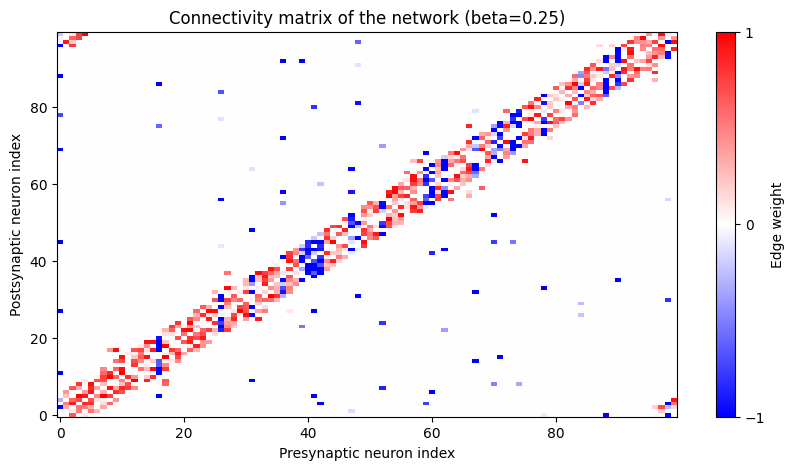

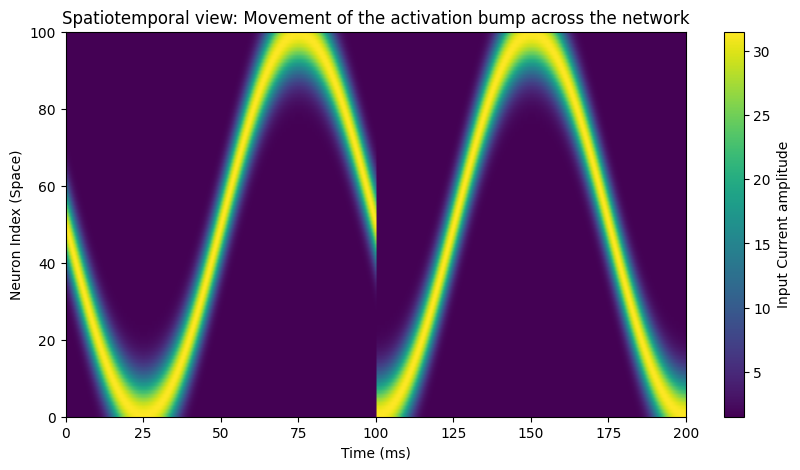

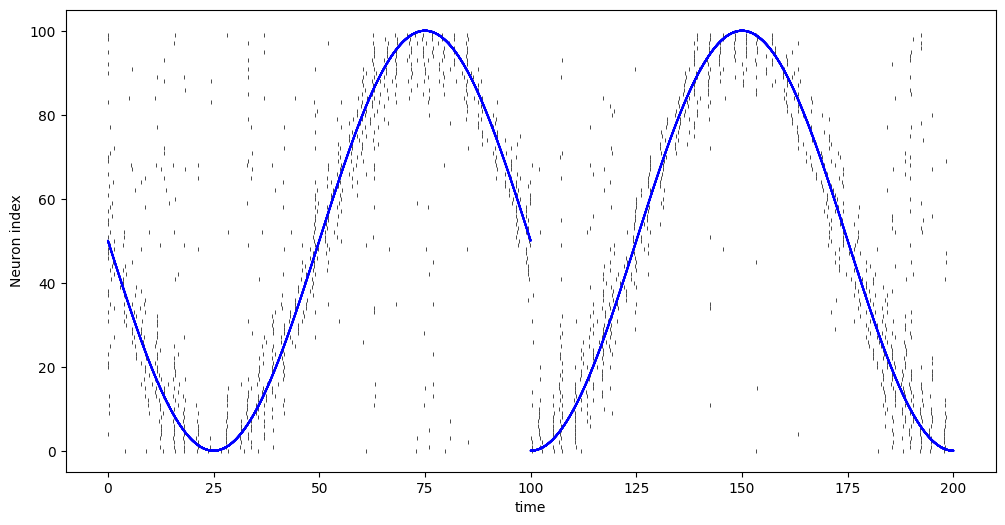

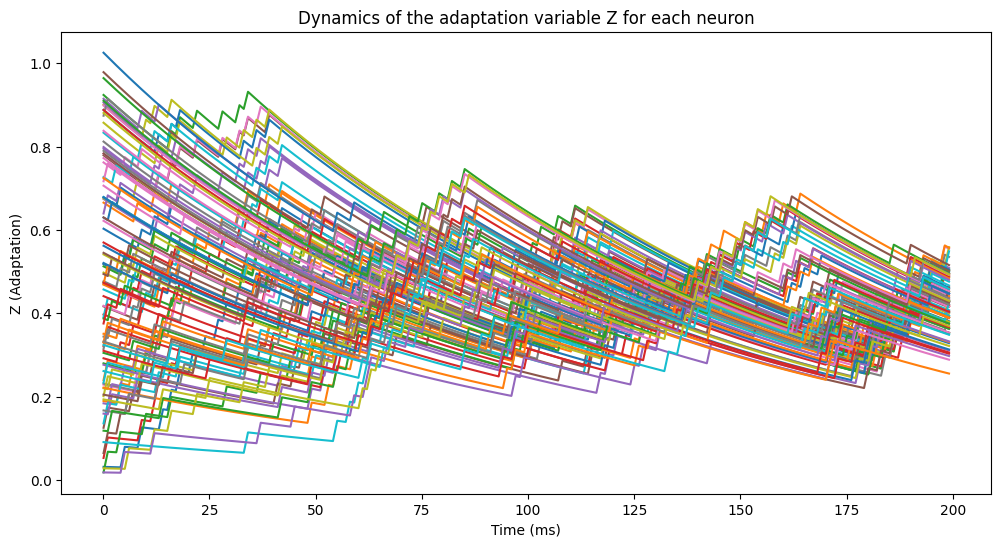

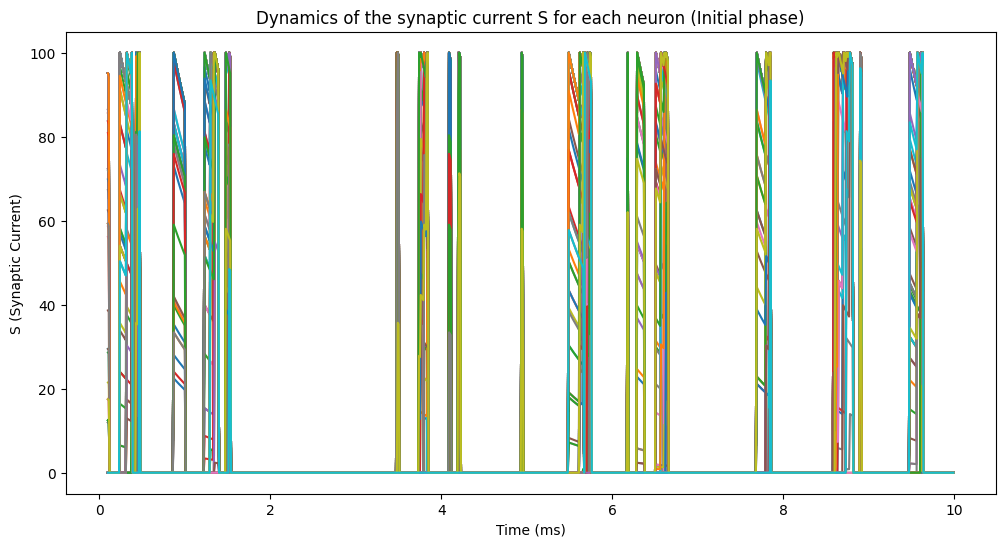

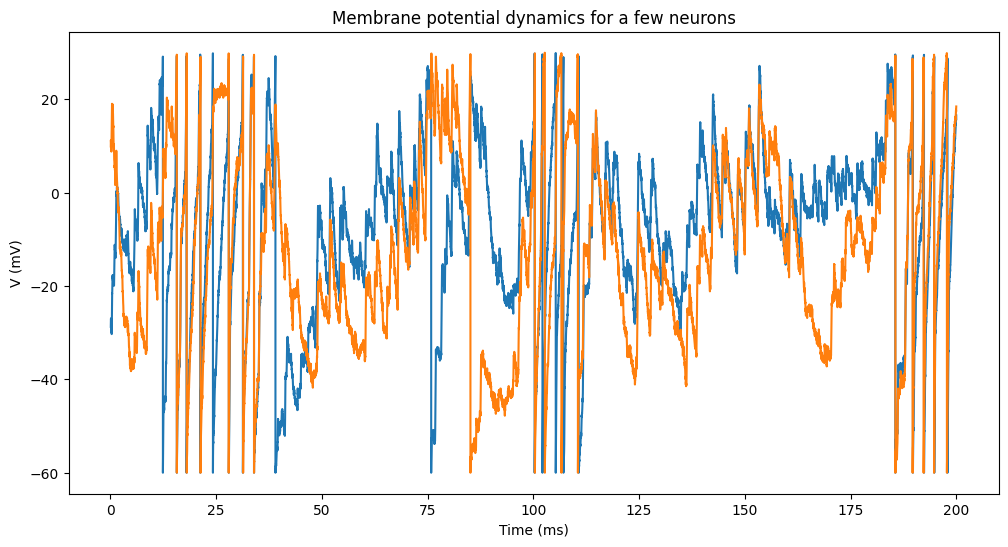

In [ ]:
# ================================================
# MAIN EXECUTION
# ================================================
# Modify config in Cell 2, then rerun only this cell.

spike_mon, state_mon, I_oscillatory_matrix, t_vec, time_steps, A, M, Wsyn_matrix, G_nx, is_inhibitory = run_simulation(config)

metrics = compute_metrics(spike_mon, config)
track = compute_raster_bump_tracking(spike_mon, config)
print(f"Active neurons  : {metrics['active_neurons']} / {config['N']}")
print(f"Inhibitory neurons: {int(is_inhibitory.sum())} / {config['N']}")
print(f"Mean firing rate : {metrics['mean_firing_rate']:.2f} Hz")
print(f"Std firing rate : {metrics['std_firing_rate']:.2f} Hz")
print(f"Synchrony index : {metrics['synchrony_index']:.4f}")
print(f"Tracking score : {track['tracking_score']:.4f}")
print(f"Mean abs error : {track['mean_abs_error']:.4f}")
print(f"Coverage : {track['coverage']:.4f}")

plot_results(spike_mon, state_mon, A, M, I_oscillatory_matrix, t_vec, config)


# Sweep

In [16]:
# ================================================
# PARAMETRIC SWEEP (beta x k)
# ================================================
# Each call to run_simulation() starts from a clean Brian2 state (internal start_scope).
# beta grid focused on the low range (0-0.15), following Shanahan (2008)'s finding
# that dynamical complexity peaks in a narrow window there rather than being spread
# evenly up to beta=1. n_seeds>1 repeats each (beta,k) point with different seeds
# for a rough estimate of run-to-run variability (bump this up once you have time).

from itertools import product
import pandas as pd

beta_values = [0.0, 0.15, 0.25, 0.5, 1.0]
k_values = [4, 6, 10]
n_seeds = 1

results = []
for beta, k in product(beta_values, k_values):
    for seed_offset in range(n_seeds):
        cfg = {
            **config, "beta": beta, "k": k,
            "seed_graph": config["seed_graph"] + seed_offset,
            "seed_weights": config["seed_weights"] + seed_offset,
        }
        spike_m, _, _, _, _, _, _, _, G_nx, is_inhib = run_simulation(cfg, verbose=False)

        m = compute_metrics(spike_m, cfg)
        isi_metrics = compute_isi_cv(spike_m, cfg)
        topo = compute_network_metrics(G_nx, cfg)
        track = compute_raster_bump_tracking(spike_m, cfg)

        results.append({
            "beta": beta, "k": k, "seed_offset": seed_offset,
            "mean_firing_rate": m["mean_firing_rate"],
            "std_firing_rate": m["std_firing_rate"],
            "active_neurons": m["active_neurons"],
            "synchrony_index": m["synchrony_index"],
            "n_inhibitory": int(is_inhib.sum()),
            **isi_metrics,
            **topo,
            "tracking_score": track["tracking_score"],
            "mean_abs_error": track["mean_abs_error"],
        })
        print(f"beta={beta:.2f}, k={k:2d}, seed={seed_offset} -> firing={m['mean_firing_rate']:6.1f} Hz,"
              f" sync={m['synchrony_index']:.3f}, CV={isi_metrics['cv_mean']:.3f},"
              f" C={topo['C']:.3f}, L={topo['L']:.3f}, omega={topo['omega']:.3f},"
              f" track_score={track['tracking_score']:.3f}", f" mean_abs_error={track['mean_abs_error']:.3f}")

df = pd.DataFrame(results)
df.to_csv("sweep_results_dale.csv", index=False)
df


beta=0.00, k= 4, seed=0 -> firing=  71.8 Hz, sync=0.344, CV=1.418, C=0.500, L=12.879, omega=-0.722, track_score=0.817  mean_abs_error=2.394
beta=0.00, k= 6, seed=0 -> firing=  74.8 Hz, sync=0.400, CV=1.462, C=0.600, L=8.758, omega=-0.686, track_score=0.791  mean_abs_error=2.755
beta=0.00, k=10, seed=0 -> firing=  72.7 Hz, sync=0.381, CV=1.400, C=0.667, L=5.455, omega=-0.593, track_score=0.806  mean_abs_error=2.527
beta=0.15, k= 4, seed=0 -> firing=  80.4 Hz, sync=0.358, CV=1.390, C=0.326, L=4.456, omega=-0.210, track_score=0.775  mean_abs_error=2.267
beta=0.15, k= 6, seed=0 -> firing=  77.1 Hz, sync=0.302, CV=1.364, C=0.344, L=3.206, omega=-0.145, track_score=0.736  mean_abs_error=2.944
beta=0.15, k=10, seed=0 -> firing=  83.5 Hz, sync=0.373, CV=1.275, C=0.394, L=2.520, omega=-0.118, track_score=0.724  mean_abs_error=2.586
beta=0.25, k= 4, seed=0 -> firing=  77.3 Hz, sync=0.254, CV=1.344, C=0.232, L=4.093, omega=-0.139, track_score=0.754  mean_abs_error=2.569
beta=0.25, k= 6, seed=0 ->

,beta,k,seed_offset,mean_firing_rate,std_firing_rate,active_neurons,synchrony_index,n_inhibitory,cv_mean,cv_std,cv2_mean,cv2_std,C,L,omega,tracking_score,mean_abs_error
0,0.00,4,0,71.75,22.851422,100,0.343827,25,1.418201,0.345388,1.089204,0.324359,0.500000,12.878788,-0.722265,0.816589,2.394231
1,0.00,6,0,74.85,21.171384,100,0.399849,25,1.461698,0.349706,1.027749,0.292299,0.600000,8.757576,-0.686210,0.790811,2.754876
2,0.00,10,0,72.70,19.240842,100,0.380725,25,1.399747,0.298501,1.031642,0.290045,0.666667,5.454545,-0.592763,0.805718,2.527469
3,0.15,4,0,80.40,21.664256,100,0.357539,25,1.390476,0.389268,1.015452,0.258759,0.325667,4.455960,-0.210437,0.775478,2.266658
4,0.15,6,0,77.10,18.962858,100,0.302205,25,1.364164,0.348882,0.983891,0.246200,0.344341,3.206061,-0.145054,0.736467,2.943938
5,0.15,10,0,83.50,21.430119,100,0.373040,25,1.275185,0.333032,0.925646,0.251838,0.394213,2.520202,-0.118124,0.723515,2.586055
6,0.25,4,0,77.30,17.991943,100,0.254463,25,1.344407,0.298876,0.989769,0.272649,0.232238,4.092525,-0.138671,0.754435,2.569027
7,0.25,6,0,84.50,21.254411,100,0.384087,25,1.322934,0.331991,0.964205,0.230389,0.273222,3.078384,-0.112338,0.741782,2.446766
8,0.25,10,0,81.30,18.064053,100,0.350696,25,1.292683,0.324268,0.941582,0.248559,0.303870,2.404242,-0.074616,0.710190,2.767762
9,0.50,4,0,92.90,22.651490,100,0.294573,25,1.236914,0.336130,0.853797,0.222634,0.104810,3.564444,-0.023509,0.666021,2.800539


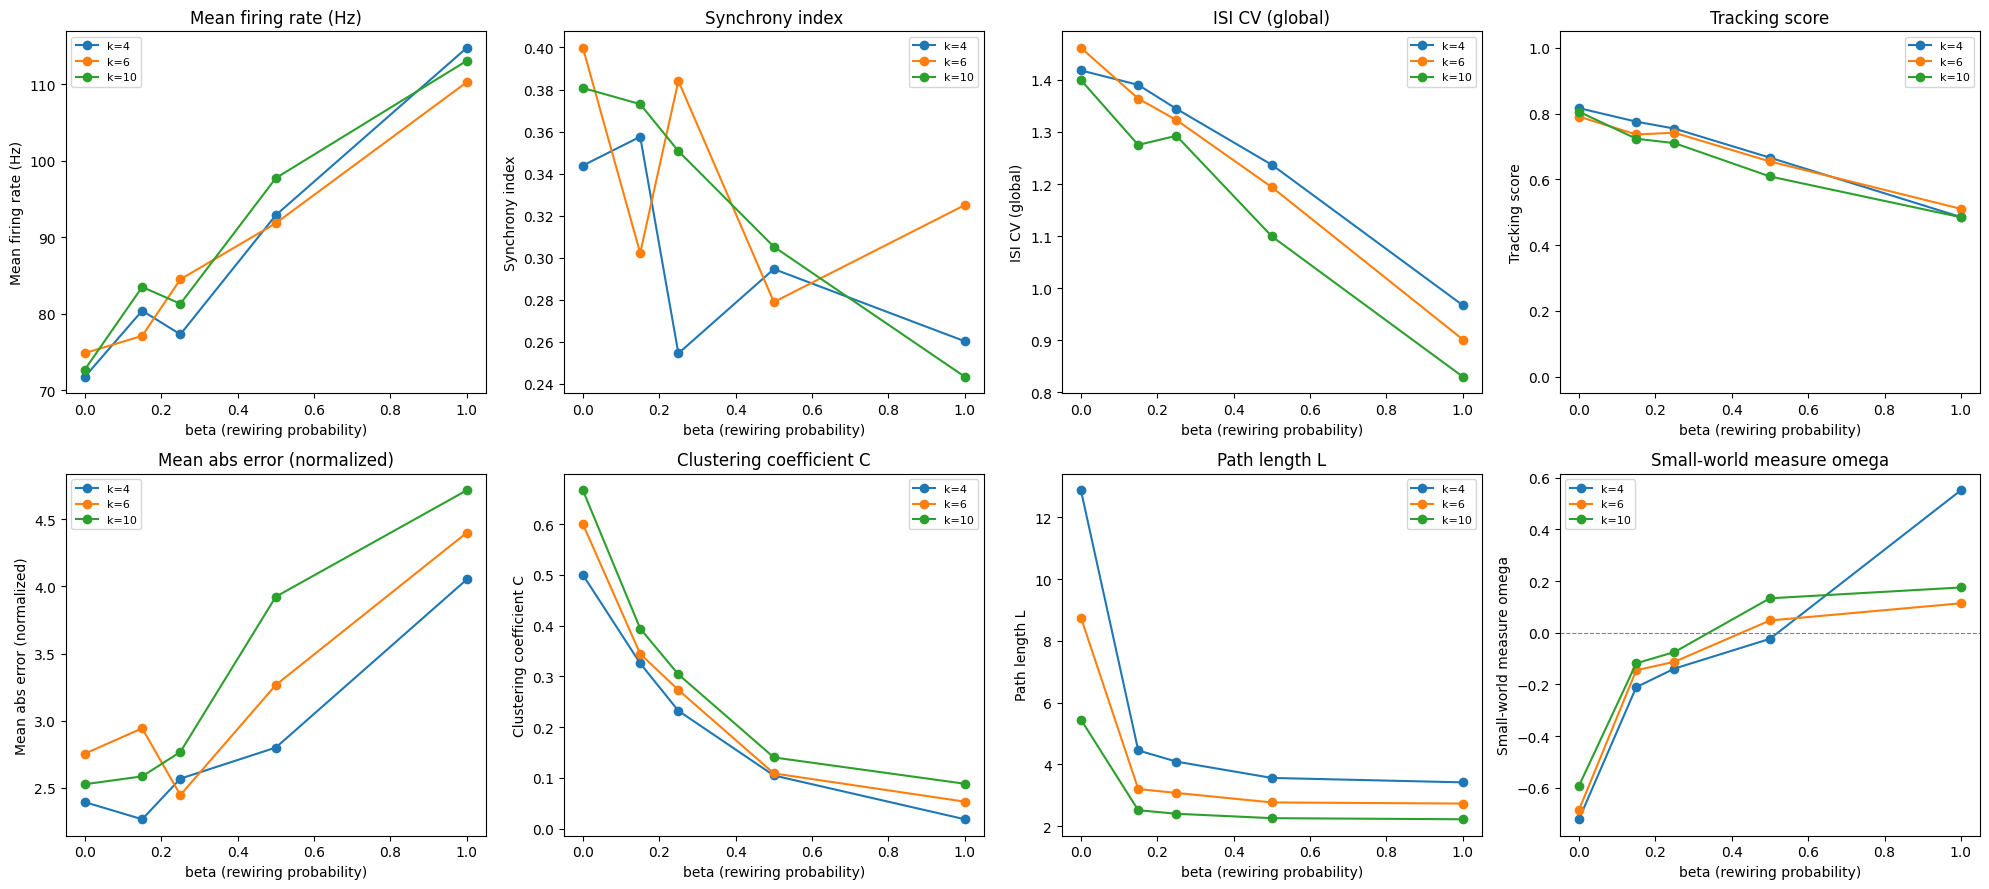

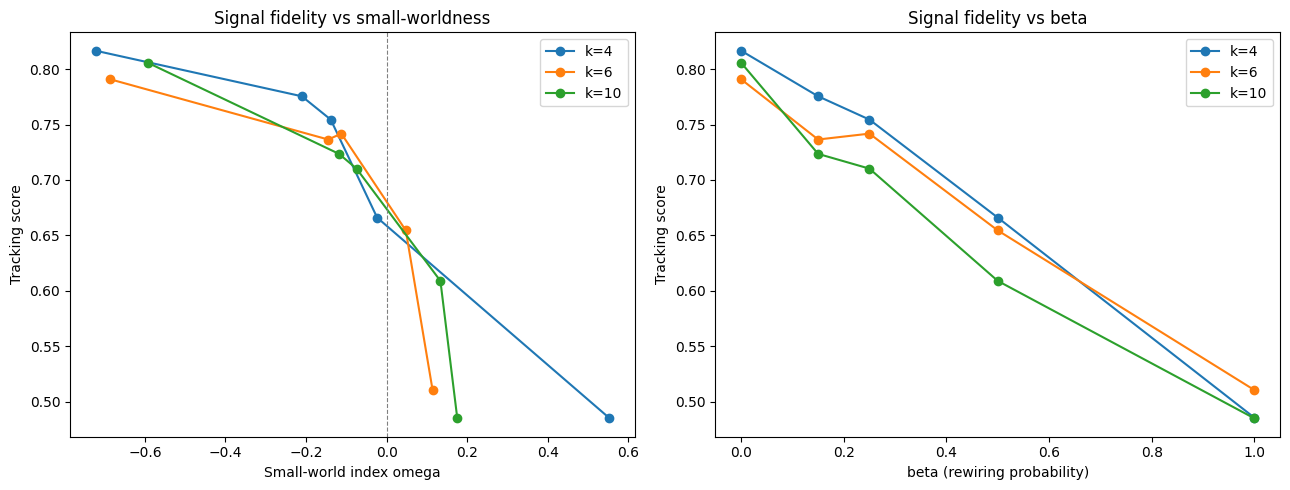

In [17]:
# ================================================
# SWEEP PLOTS
# ================================================
df_mean = df.groupby(["beta", "k"], as_index=False).mean(numeric_only=True)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

sweep_metrics = [
    ("mean_firing_rate", "Mean firing rate (Hz)"),
    ("synchrony_index", "Synchrony index"),
    ("cv_mean", "ISI CV (global)"),
    ("tracking_score", "Tracking score"),
    ("mean_abs_error", "Mean abs error (normalized)"),
    ("C", "Clustering coefficient C"),
    ("L", "Path length L"),
    ("omega", "Small-world measure omega"),
]

for ax, (col, label) in zip(axes.flat, sweep_metrics):
    for k in sorted(df_mean["k"].unique()):
        sub = df_mean[df_mean["k"] == k].sort_values("beta")
        ax.plot(sub["beta"], sub[col], marker="o", label=f"k={k}")
    ax.set_xlabel("beta (rewiring probability)")
    ax.set_ylabel(label)
    ax.set_title(label)
    if col == "omega":
        ax.axhline(0.0, color="gray", ls="--", lw=0.8)
    if col == "tracking_score":
        ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("sweep_overview_dale.png", dpi=130)
plt.show()

# Relation topology <-> signal fidelity (the core small-world hypothesis test)
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(13, 5))
for k in sorted(df_mean["k"].unique()):
    sub = df_mean[df_mean["k"] == k].sort_values("beta")
    ax2a.plot(sub["omega"], sub["tracking_score"], marker="o", label=f"k={k}")
    ax2b.plot(sub["beta"], sub["tracking_score"], marker="o", label=f"k={k}")
ax2a.set_xlabel("Small-world index omega")
ax2a.set_ylabel("Tracking score")
ax2a.set_title("Signal fidelity vs small-worldness")
ax2a.axvline(0.0, color="gray", ls="--", lw=0.8)
ax2a.legend()
ax2b.set_xlabel("beta (rewiring probability)")
ax2b.set_ylabel("Tracking score")
ax2b.set_title("Signal fidelity vs beta")
ax2b.legend()
plt.tight_layout()
plt.savefig("tracking_vs_omega_dale.png", dpi=130)
plt.show()


# H1 — long-range excitatory vs long-range inhibitory

Compares the Shanahan convention (long-range = excitatory, inhibitory kept
local, the default used above) against the opposite (long-range =
inhibitory, excitatory kept local, closer to the original pre-Dale
intuition). Same beta x k grid on both, same seeds, so the only thing that
differs is `long_range_type`.

In [ ]:
# ================================================
# H1 COMPARISON SWEEP: long_range_type = "excitatory" vs "inhibitory"
# ================================================
beta_values_h1 = [0.0, 0.1, 0.25, 0.5, 1.0]
k_values_h1 = [4, 6, 10]
n_seeds_h1 = 1

results_h1 = []
for long_range_type in ["excitatory", "inhibitory"]:
    for beta, k in product(beta_values_h1, k_values_h1):
        for seed_offset in range(n_seeds_h1):
            cfg = {
                **config, "beta": beta, "k": k, "long_range_type": long_range_type,
                "seed_graph": config["seed_graph"] + seed_offset,
                "seed_weights": config["seed_weights"] + seed_offset,
            }
            spike_m, _, _, _, _, _, _, _, G_nx, is_inhib = run_simulation(cfg, verbose=False)

            m = compute_metrics(spike_m, cfg)
            isi_metrics = compute_isi_cv(spike_m, cfg)
            topo = compute_network_metrics(G_nx, cfg)
            track = compute_raster_bump_tracking(spike_m, cfg)

            results_h1.append({
                "long_range_type": long_range_type, "beta": beta, "k": k, "seed_offset": seed_offset,
                "mean_firing_rate": m["mean_firing_rate"],
                "synchrony_index": m["synchrony_index"],
                **isi_metrics,
                **topo,
                "tracking_score": track["tracking_score"],
                "mean_abs_error": track["mean_abs_error"],
            })
            print(f"[{long_range_type:>10}] beta={beta:.2f}, k={k:2d}, seed={seed_offset} -> firing={m['mean_firing_rate']:6.1f} Hz,"
                  f" sync={m['synchrony_index']:.3f}, track_score={track['tracking_score']:.3f},"
                  f" mean_abs_error={track['mean_abs_error']:.3f}, omega={topo['omega']:.3f}")

df_h1 = pd.DataFrame(results_h1)
df_h1.to_csv("sweep_results_h1.csv", index=False)
df_h1


[excitatory] beta=0.00, k= 4, seed=0 -> firing= 232.7 Hz, sync=1.418, track_score=0.334, mean_abs_error=5.000, omega=-0.722
[excitatory] beta=0.00, k= 6, seed=0 -> firing= 239.9 Hz, sync=1.358, track_score=0.351, mean_abs_error=5.772, omega=-0.686
[excitatory] beta=0.00, k=10, seed=0 -> firing= 313.9 Hz, sync=1.127, track_score=0.235, mean_abs_error=8.634, omega=-0.593
[excitatory] beta=0.10, k= 4, seed=0 -> firing= 268.8 Hz, sync=1.252, track_score=0.239, mean_abs_error=3.885, omega=-0.205
[excitatory] beta=0.10, k= 6, seed=0 -> firing= 275.4 Hz, sync=1.186, track_score=0.311, mean_abs_error=6.330, omega=-0.188
[excitatory] beta=0.10, k=10, seed=0 -> firing= 208.9 Hz, sync=1.340, track_score=0.377, mean_abs_error=13.526, omega=-0.137
[excitatory] beta=0.25, k= 4, seed=0 -> firing= 262.6 Hz, sync=1.259, track_score=0.214, mean_abs_error=5.228, omega=-0.139
[excitatory] beta=0.25, k= 6, seed=0 -> firing= 235.8 Hz, sync=1.332, track_score=0.366, mean_abs_error=4.203, omega=-0.112
[excita

,long_range_type,beta,k,seed_offset,mean_firing_rate,synchrony_index,cv_mean,cv_std,cv2_mean,cv2_std,C,L,omega,tracking_score,mean_abs_error
0,excitatory,0.00,4,0,232.65,1.418255,3.159059,0.158172,0.232090,0.020624,0.500000,12.878788,-0.722265,0.333762,4.999531
1,excitatory,0.00,6,0,239.90,1.357860,3.074548,0.127929,0.261990,0.027806,0.600000,8.757576,-0.686210,0.351216,5.771780
2,excitatory,0.00,10,0,313.95,1.126947,3.319171,0.110174,0.240179,0.019405,0.666667,5.454545,-0.592763,0.235052,8.633843
3,excitatory,0.10,4,0,268.75,1.252422,3.966158,0.184967,0.198478,0.024827,0.321333,4.461010,-0.204601,0.238615,3.884526
4,excitatory,0.10,6,0,275.35,1.186196,2.659798,0.117567,0.199152,0.023495,0.389683,3.378586,-0.187563,0.310546,6.330479
5,excitatory,0.10,10,0,208.90,1.340116,2.355726,0.266369,0.382596,0.036178,0.443730,2.577778,-0.136850,0.377470,13.526489
6,excitatory,0.25,4,0,262.55,1.259316,3.798451,0.176279,0.204679,0.027294,0.232238,4.092525,-0.138671,0.214193,5.228095
7,excitatory,0.25,6,0,235.85,1.332420,3.296102,0.180778,0.327339,0.032181,0.273222,3.078384,-0.112338,0.366017,4.203441
8,excitatory,0.25,10,0,229.15,1.193105,2.464759,0.128041,0.434125,0.039584,0.303870,2.404242,-0.074616,0.300326,6.552106
9,excitatory,0.50,4,0,252.30,1.199540,2.503439,0.089055,0.345985,0.029066,0.104810,3.564444,-0.023509,0.277515,6.266314


## H1 comparison plots

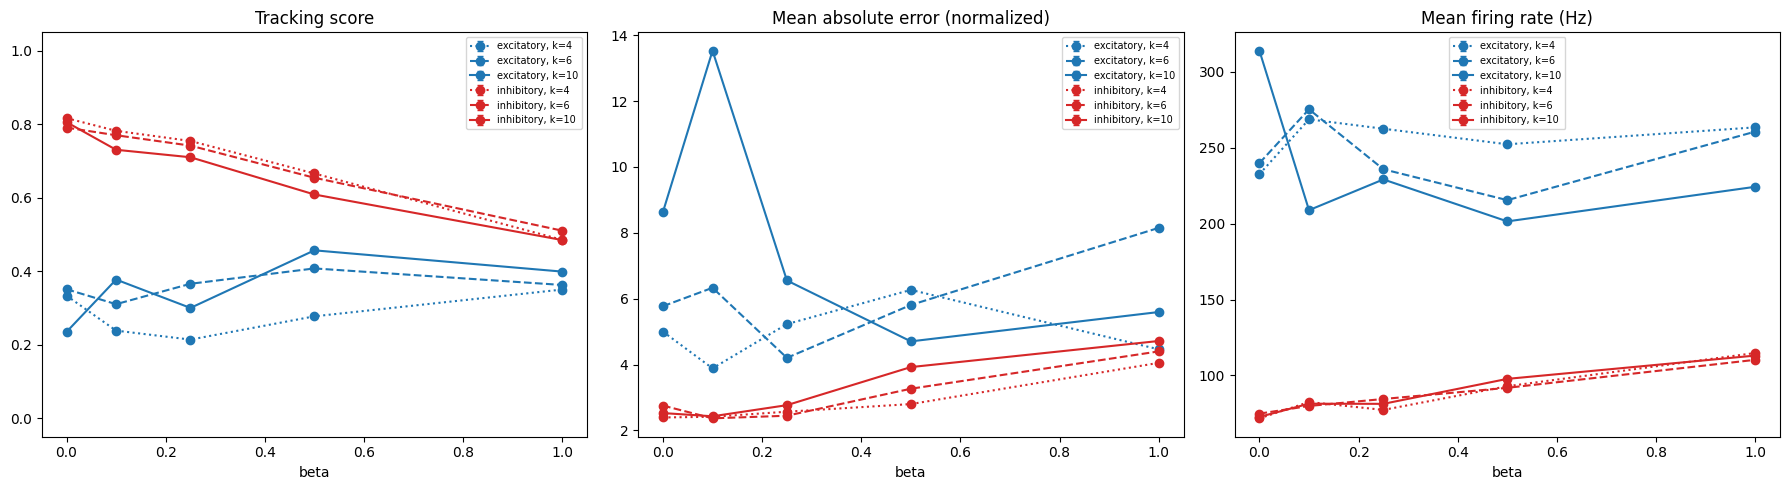

                tracking_score           mean_abs_error            \
                          mean       std           mean       std   
long_range_type                                                     
excitatory            0.332120  0.069277       6.274357  2.407712   
inhibitory            0.687504  0.115821       3.055337  0.810135   

                mean_firing_rate            synchrony_index            
                            mean        std            mean       std  
long_range_type                                                        
excitatory                245.65  29.504534        1.165131  0.205521  
inhibitory                 88.46  14.536619        0.328668  0.053221  


In [ ]:
# ================================================
# H1 COMPARISON PLOTS (mean +/- std across seeds)
# ================================================
df_h1_mean = df_h1.groupby(["long_range_type", "beta", "k"], as_index=False).mean(numeric_only=True)
df_h1_std = df_h1.groupby(["long_range_type", "beta", "k"], as_index=False).std(numeric_only=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {"excitatory": "tab:blue", "inhibitory": "tab:red"}
styles = {4: ":", 6: "--", 10: "-"}

for lrt in ["excitatory", "inhibitory"]:
    for k in k_values_h1:
        sub_m = df_h1_mean[(df_h1_mean["long_range_type"] == lrt) & (df_h1_mean["k"] == k)].sort_values("beta")
        sub_s = df_h1_std[(df_h1_std["long_range_type"] == lrt) & (df_h1_std["k"] == k)].sort_values("beta")
        label = f"{lrt}, k={k}"
        axes[0].errorbar(sub_m["beta"], sub_m["tracking_score"], yerr=sub_s["tracking_score"],
                          color=colors[lrt], ls=styles[k], marker="o", capsize=2, label=label)
        axes[1].errorbar(sub_m["beta"], sub_m["mean_abs_error"], yerr=sub_s["mean_abs_error"],
                          color=colors[lrt], ls=styles[k], marker="o", capsize=2, label=label)
        axes[2].errorbar(sub_m["beta"], sub_m["mean_firing_rate"], yerr=sub_s["mean_firing_rate"],
                          color=colors[lrt], ls=styles[k], marker="o", capsize=2, label=label)

axes[0].set_title("Tracking score")
axes[0].set_ylim(-0.05, 1.05)
axes[1].set_title("Mean absolute error (normalized)")
axes[2].set_title("Mean firing rate (Hz)")
for ax in axes:
    ax.set_xlabel("beta")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("h1_comparison.png", dpi=130)
plt.show()

# Direct summary: average tracking_score per long_range_type (across all beta,k,seeds)
summary_h1 = df_h1.groupby("long_range_type")[["tracking_score", "mean_abs_error", "mean_firing_rate", "synchrony_index"]].agg(["mean", "std"])
print(summary_h1)


# H4 — does small-world topology maximize signal fidelity?

Reuses the main sweep (`df`, Shanahan/excitatory-long-range convention) —
no new simulation needed. Plots tracking fidelity against omega directly,
with the small-world zone (omega close to 0) highlighted, to check whether
fidelity peaks there rather than at the lattice or random extremes.

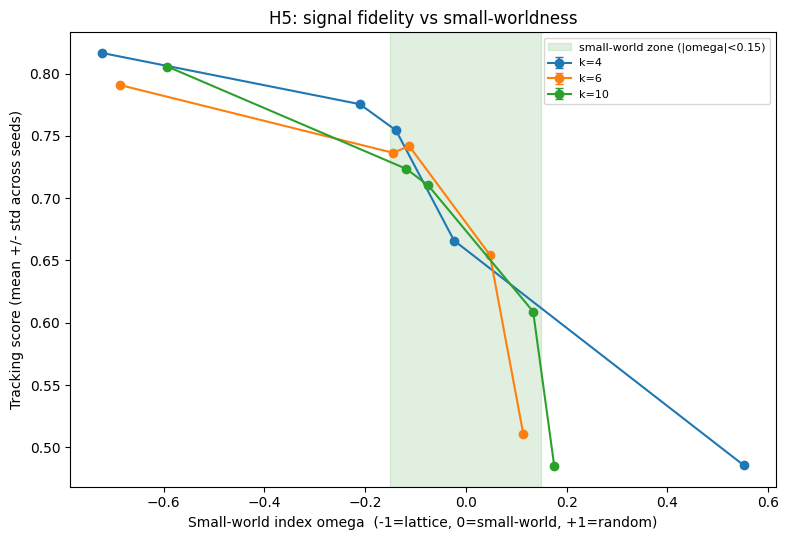

tracking_score -- lattice (omega<-0.4)      : 0.804 +/- 0.013  (n=3)
tracking_score -- small-world (|omega|<0.15): 0.654 +/- 0.107  (n=12)
tracking_score -- random (omega>0.4)        : 0.494 +/- 0.015  (n=3)


In [ ]:
# ================================================
# H4: signal fidelity vs small-worldness (reuses df from the main sweep)
# ================================================
df_h4_mean = df.groupby(["beta", "k"], as_index=False).mean(numeric_only=True)
df_h4_std = df.groupby(["beta", "k"], as_index=False).std(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 5.5))
for k in sorted(df_h4_mean["k"].unique()):
    sub_m = df_h4_mean[df_h4_mean["k"] == k].sort_values("omega")
    sub_s = df_h4_std[df_h4_std["k"] == k].sort_values("omega")
    ax.errorbar(sub_m["omega"], sub_m["tracking_score"], yerr=sub_s["tracking_score"],
                marker="o", capsize=3, label=f"k={k}")

ax.axvspan(-0.15, 0.15, color="green", alpha=0.12, label="small-world zone (|omega|<0.15)")
ax.set_xlabel("Small-world index omega  (-1=lattice, 0=small-world, +1=random)")
ax.set_ylabel("Tracking score (mean +/- std across seeds)")
ax.set_title("H4: signal fidelity vs small-worldness")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("h4_fidelity_vs_omega.png", dpi=130)
plt.show()

# Quantify: mean +/- std of tracking_score in the small-world zone vs the two extremes
# (computed on the raw per-seed rows in df, not the already-averaged df_h4_mean)
df_zone = df.groupby(["beta", "k"], as_index=False).mean(numeric_only=True)
betas_sw = df_zone[df_zone["omega"].abs() < 0.15]["beta"]
betas_lattice = df_zone[df_zone["omega"] < -0.4]["beta"]
betas_random = df_zone[df_zone["omega"] > 0.4]["beta"]
sw_zone = df[df["beta"].isin(betas_sw)]
lattice_zone = df[df["beta"].isin(betas_lattice)]
random_zone = df[df["beta"].isin(betas_random)]

score_lattice_mean = lattice_zone["tracking_score"].mean()
score_lattice_std = lattice_zone["tracking_score"].std()
score_sw_mean = sw_zone["tracking_score"].mean()
score_sw_std = sw_zone["tracking_score"].std()
score_random_mean = random_zone["tracking_score"].mean()
score_random_std = random_zone["tracking_score"].std()

print(f"tracking_score -- lattice (omega<-0.4)      : {score_lattice_mean:.3f} +/- {score_lattice_std:.3f}  (n={len(lattice_zone)})")
print(f"tracking_score -- small-world (|omega|<0.15): {score_sw_mean:.3f} +/- {score_sw_std:.3f}  (n={len(sw_zone)})")
print(f"tracking_score -- random (omega>0.4)        : {score_random_mean:.3f} +/- {score_random_std:.3f}  (n={len(random_zone)})")


# H2 & H3 — thickness-dependent delay and weight

H2: long-range connections conduct faster (shorter delay) than local ones,
following classic cable theory (thicker fiber -> higher conduction
velocity). H3: long-range connections carry a stronger synaptic weight
(more "capacity"). Both compared against the uniform/baseline condition,
on a light grid (k=10 only, a few beta values) to keep this fast --
widen the grid later if the direction looks promising.

In [ ]:
# ================================================
# H2/H3 COMPARISON SWEEP (light grid: k=10 only)
# ================================================
beta_values_h2h3 = [0.0, 0.1, 0.25, 0.5, 1.0]
k_h2h3 = 10
n_seeds_h2h3 = 1

conditions = {
    "baseline" :                   {"use_conduction_delays": False, "enable_thickness_weight": False},
    "uniform_delay_control" :      {"use_conduction_delays": True,  "v_local": 2.0, "v_long": 2.0, "enable_thickness_weight": False},
    "H2_fast_longrange_delay":     {"use_conduction_delays": True,  "v_local": 2.0, "v_long": 8.0, "enable_thickness_weight": False},
    "H3_strong_longrange_weight" : {"use_conduction_delays": False, "enable_thickness_weight": True},
    "H2+H3_combined" :             {"use_conduction_delays": True,  "v_local": 2.0, "v_long": 8.0, "enable_thickness_weight": True},
}

results_h2h3 = []
for cond_name, cond_overrides in conditions.items():
    for beta in beta_values_h2h3:
        for seed_offset in range(n_seeds_h2h3):
            cfg = {
                **config, "beta": beta, "k": k_h2h3, **cond_overrides,
                "seed_graph": config["seed_graph"] + seed_offset,
                "seed_weights": config["seed_weights"] + seed_offset,
            }
            spike_m, _, _, _, _, _, _, _, G_nx, is_inhib = run_simulation(cfg, verbose=False)

            m = compute_metrics(spike_m, cfg)
            track = compute_raster_bump_tracking(spike_m, cfg)
            topo = compute_network_metrics(G_nx, cfg)

            results_h2h3.append({
                "condition": cond_name, "beta": beta, "seed_offset": seed_offset,
                "mean_firing_rate": m["mean_firing_rate"],
                "synchrony_index": m["synchrony_index"],
                "tracking_score": track["tracking_score"],
                "mean_abs_error": track["mean_abs_error"],
                "omega": topo["omega"],
            })
            print(f"[{cond_name:>26}] beta={beta:.2f} -> firing={m['mean_firing_rate']:6.1f} Hz,"
                  f" tracking_score={track['tracking_score']:.3f}, mean_abs_error={track['mean_abs_error']:.3f},")

df_h2h3 = pd.DataFrame(results_h2h3)
df_h2h3.to_csv("sweep_results_h2h3.csv", index=False)
df_h2h3


[                  baseline] beta=0.00 -> firing=  72.7 Hz, tracking_score=0.806, mean_abs_error=2.527,
[                  baseline] beta=0.10 -> firing=  81.4 Hz, tracking_score=0.731, mean_abs_error=2.430,
[                  baseline] beta=0.25 -> firing=  81.3 Hz, tracking_score=0.710, mean_abs_error=2.768,
[                  baseline] beta=0.50 -> firing=  97.8 Hz, tracking_score=0.609, mean_abs_error=3.923,
[                  baseline] beta=1.00 -> firing= 113.1 Hz, tracking_score=0.485, mean_abs_error=4.715,
[     uniform_delay_control] beta=0.00 -> firing= 208.6 Hz, tracking_score=0.411, mean_abs_error=13.761,
[     uniform_delay_control] beta=0.10 -> firing= 267.5 Hz, tracking_score=0.342, mean_abs_error=9.598,
[     uniform_delay_control] beta=0.25 -> firing= 296.4 Hz, tracking_score=0.333, mean_abs_error=8.308,
[     uniform_delay_control] beta=0.50 -> firing= 345.2 Hz, tracking_score=0.313, mean_abs_error=5.943,
[     uniform_delay_control] beta=1.00 -> firing= 387.0 Hz, tra

,condition,beta,seed_offset,mean_firing_rate,synchrony_index,tracking_score,mean_abs_error,omega
0,baseline,0.00,0,72.70,0.380725,0.805718,2.527469,-0.592763
1,baseline,0.10,0,81.40,0.391474,0.730554,2.429862,-0.136850
2,baseline,0.25,0,81.30,0.350696,0.710190,2.767762,-0.074616
3,baseline,0.50,0,97.75,0.305193,0.608920,3.923426,0.133592
4,baseline,1.00,0,113.10,0.243331,0.484908,4.715338,0.175501
5,uniform_delay_control,0.00,0,208.60,0.674893,0.411175,13.760772,-0.592763
6,uniform_delay_control,0.10,0,267.50,0.387468,0.342096,9.597806,-0.136850
7,uniform_delay_control,0.25,0,296.35,0.331017,0.333019,8.308237,-0.074616
8,uniform_delay_control,0.50,0,345.20,0.271059,0.313430,5.942839,0.133592
9,uniform_delay_control,1.00,0,387.00,0.218260,0.291896,6.119427,0.175501


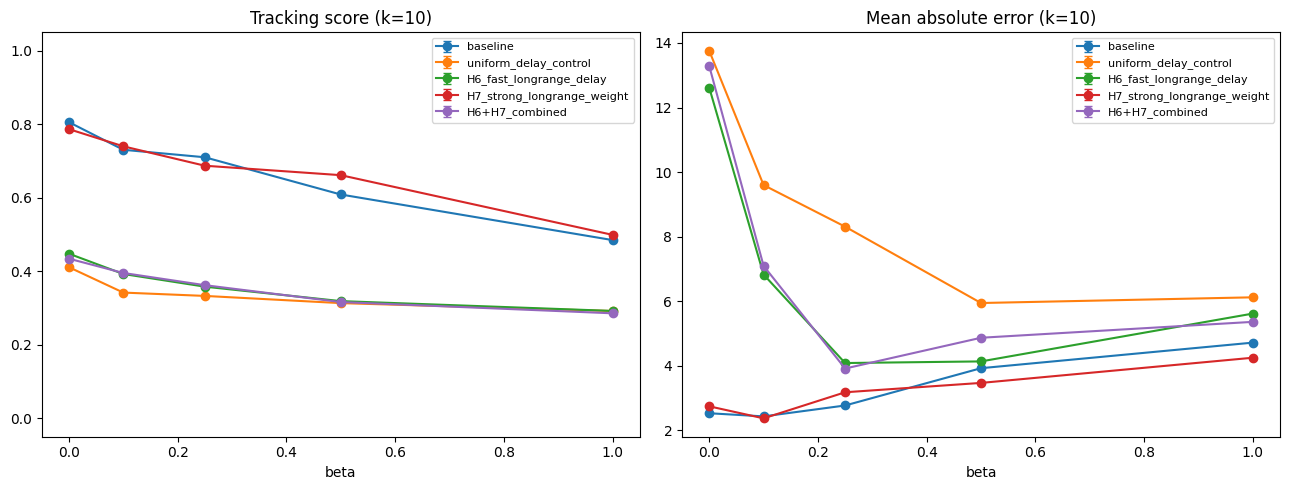

                           tracking_score           mean_abs_error            \
                                     mean       std           mean       std   
condition                                                                      
H6+H7_combined                   0.358813  0.059596       6.904442  3.751246   
H6_fast_longrange_delay          0.361964  0.061372       6.655343  3.523062   
H7_strong_longrange_weight       0.674901  0.109502       3.200737  0.719123   
baseline                         0.668058  0.124170       3.272771  1.003165   
uniform_delay_control            0.338323  0.045069       8.745816  3.194595   

                           mean_firing_rate             
                                       mean        std  
condition                                               
H6+H7_combined                       334.67  65.125202  
H6_fast_longrange_delay              334.43  65.236441  
H7_strong_longrange_weight            89.15  16.201427  
baseline         

In [ ]:
# ================================================
# H2/H3 COMPARISON PLOTS
# ================================================
df_h2h3_mean = df_h2h3.groupby(["condition", "beta"], as_index=False).mean(numeric_only=True)
df_h2h3_std = df_h2h3.groupby(["condition", "beta"], as_index=False).std(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for cond_name in conditions.keys():
    sub_m = df_h2h3_mean[df_h2h3_mean["condition"] == cond_name].sort_values("beta")
    sub_s = df_h2h3_std[df_h2h3_std["condition"] == cond_name].sort_values("beta")
    axes[0].errorbar(sub_m["beta"], sub_m["tracking_score"], yerr=sub_s["tracking_score"],
                      marker="o", capsize=3, label=cond_name)
    axes[1].errorbar(sub_m["beta"], sub_m["mean_abs_error"], yerr=sub_s["mean_abs_error"],
                      marker="o", capsize=3, label=cond_name)

axes[0].set_title("Tracking score (k=10)")
axes[0].set_ylim(-0.05, 1.05)
axes[1].set_title("Mean absolute error (k=10)")
for ax in axes:
    ax.set_xlabel("beta")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("h2_h3_comparison.png", dpi=130)
plt.show()

summary_h2h3 = df_h2h3.groupby("condition")[["tracking_score", "mean_abs_error", "mean_firing_rate"]].agg(["mean", "std"])
print(summary_h2h3)
